# L5 — Nghiên cứu POI: chọn địa hạt nào, bao nhiêu cụm, và POI có dự báo được nhu cầu không?

Bạn đặt hai câu hỏi:

> 1. **Lấy bao nhiêu cụm?**
> 2. **Lấy địa hạt (đơn vị không gian) ra sao?**

Notebook này trả lời cả hai **bằng số đo**, không bằng phán đoán. Nhưng trước đó phải trả
lời một câu thứ ba mà hai câu trên phụ thuộc vào:

> 3. **Dữ liệu POI của ta có đủ tốt để cụm có nghĩa không?**

Nếu câu 3 là "không", thì mọi cụm tìm được sẽ là cụm của **công sức bản đồ hoá OSM**, chứ
không phải cụm của **hoạt động kinh tế**. Nó sẽ trông y hệt một phát hiện.

---

## Bố cục

| § | Nội dung | Trả lời câu |
|---|---|---|
| 1 | Dữ liệu thật sự có gì — độ thưa và thiên lệch | 3 |
| 2 | **Chọn địa hạt** — ô r8 / ô mở rộng / xã | 2 |
| 3 | **Chọn đặc trưng** — số đếm hay tỉ trọng? | (nền cho 1) |
| 4 | **Chọn số cụm** — silhouette + độ ổn định | 1 |
| 5 | Cụm tìm được là gì — đặt tên và vẽ | — |
| 6 | **Phép thử quyết định** — POI có dự báo được nhu cầu thật không? | 3 |
| 7 | Cách khác: cụm trên chính điểm POI (DBSCAN) | 2 |

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
from scipy.stats import spearmanr
from sklearn.cluster import DBSCAN, KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.preprocessing import StandardScaler

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))
import h3  # noqa: E402

plt.rcParams.update({"figure.dpi": 120, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False})
RNG = 20260807

grid = pq.read_table(ROOT / "data/processed/grid_h3_r8.parquet").to_pandas()
com = pq.read_table(ROOT / "data/processed/commune.parquet").to_pandas()
poi = pq.read_table(ROOT / "data/qa/critique/poi_extended.parquet").to_pandas()

grid["loai_xa"] = np.where(grid.commune_name.str.startswith("Phường"), "Phường", "Xã")
poi = poi[poi.h3_r8.isin(set(grid.h3_r8))].copy()
print(f"{len(poi):,} POI trong ranh giới Hà Nội · {poi.poi_class.nunique()} lớp")
display(poi.groupby("tang").size().rename("số POI").to_frame().T)

20,691 POI trong ranh giới Hà Nội · 18 lớp


tang,GOC,MO_RONG
số POI,3919,16772


## §1 — Dữ liệu thật sự có gì

Hai vấn đề đã đo ở A15, nhắc lại bằng số để notebook đứng độc lập.

In [2]:
cnt = poi.pivot_table(index="h3_r8", columns="poi_class", aggfunc="size", fill_value=0)
cnt = cnt.reindex(grid.h3_r8).fillna(0).astype(int)
g = grid.set_index("h3_r8")
tong = cnt.sum(axis=1)

print("VẤN ĐỀ 1 — ĐỘ THƯA")
for nhan, c in [("taxonomy gốc (8 lớp)", cnt[[c for c in cnt.columns if c in set(poi[poi.tang=='GOC'].poi_class)]].sum(axis=1)),
                ("taxonomy mở rộng", tong)]:
    print(f"  {nhan:24s} ô có 0 POI: {(c == 0).mean():6.1%} · trung vị {c.median():.0f} · "
          f"p90 {c.quantile(0.9):.0f}")

print("\nVẤN ĐỀ 2 — THIÊN LỆCH BẢN ĐỒ HOÁ")
b = pd.DataFrame({"poi": tong, "loai": g.loai_xa,
                  "built_km2": g.built_frac * g.area_km2 * g.area_frac, "dan": g.population})
bb = b.groupby("loai").agg(poi=("poi", "sum"), built=("built_km2", "sum"), dan=("dan", "sum"),
                           o_rong=("poi", lambda x: (x == 0).mean()))
bb["poi_tren_km2_da_xay"] = bb.poi / bb.built
bb["poi_tren_10k_dan"] = bb.poi / bb.dan * 1e4
display(bb.round(3))
print(f"→ chênh lệch POI/km² đã xây dựng giữa Phường và Xã: "
      f"{bb.loc['Phường','poi_tren_km2_da_xay']/bb.loc['Xã','poi_tren_km2_da_xay']:.1f}×")

VẤN ĐỀ 1 — ĐỘ THƯA
  taxonomy gốc (8 lớp)     ô có 0 POI:  87.2% · trung vị 0 · p90 1
  taxonomy mở rộng         ô có 0 POI:  68.9% · trung vị 0 · p90 5

VẤN ĐỀ 2 — THIÊN LỆCH BẢN ĐỒ HOÁ


,poi,built,dan,o_rong,poi_tren_km2_da_xay,poi_tren_10k_dan
loai,,,,,,
Phường,17426,175.767,4117237.910,0.222,99.143,42.324
Xã,3265,441.772,4713887.975,0.749,7.391,6.926


→ chênh lệch POI/km² đã xây dựng giữa Phường và Xã: 13.4×


**Mật độ thương mại thật giữa nội thành và ngoại thành không chênh chừng đó lần trên mỗi
km² ĐÃ XÂY DỰNG.** Phần chênh còn lại là công sức bản đồ hoá của tình nguyện viên OSM.

Đây là ràng buộc chi phối toàn bộ thiết kế phía sau: **bất kỳ đặc trưng nào tỉ lệ với SỐ
LƯỢNG POI đều mang theo thiên lệch này.**

---
## §2 — Câu hỏi của bạn #2: lấy địa hạt nào?

Ba lựa chọn. Tiêu chí chọn: **đơn vị phải đủ POI để đặc trưng có nghĩa**. Một đơn vị có
0–2 POI thì vectơ đặc trưng của nó là nhiễu thuần tuý, và k-means sẽ cụm nhiễu rất vui vẻ.

In [3]:
# (a) ô r8 thô  (b) ô r8 + vùng lân cận bán kính 2 ô  (c) xã/phường
idx = list(grid.h3_r8)
pos = {c: i for i, c in enumerate(idx)}
M = cnt.loc[idx].to_numpy()

Mk = np.zeros_like(M)
for i, c in enumerate(idx):
    for nb in h3.grid_disk(c, 2):
        j = pos.get(nb)
        if j is not None:
            Mk[i] += M[j]

com_of = g.loc[idx, "commune_code"].to_numpy()
com_cnt = pd.DataFrame(M, index=idx, columns=cnt.columns).groupby(com_of).sum()

don_vi = {
    "ô r8 (0,74 km²)": pd.DataFrame(M, index=idx, columns=cnt.columns),
    "ô r8 + lân cận r=2 (~5 km²)": pd.DataFrame(Mk, index=idx, columns=cnt.columns),
    "xã/phường": com_cnt,
}
rows = []
for nhan, D in don_vi.items():
    t = D.sum(axis=1)
    rows.append({
        "địa hạt": nhan, "số đơn vị": len(D),
        "% đơn vị có 0 POI": (t == 0).mean(),
        "% đơn vị có < 10 POI": (t < 10).mean(),
        "POI trung vị": t.median(),
        "% đơn vị dùng được (≥10 POI)": (t >= 10).mean(),
    })
display(pd.DataFrame(rows).set_index("địa hạt").round(3))

,số đơn vị,% đơn vị có 0 POI,% đơn vị có < 10 POI,POI trung vị,% đơn vị dùng được (≥10 POI)
địa hạt,,,,,
"ô r8 (0,74 km²)",4400,0.689,0.933,0.0,0.067
ô r8 + lân cận r=2 (~5 km²),4400,0.078,0.527,9.0,0.473
xã/phường,126,0.000,0.040,51.0,0.960


**Kết luận §2 — chọn địa hạt:**

- **Ô r8 thô: loại.** Phần lớn ô có quá ít POI. Cụm trên đó là cụm trên nhiễu.
- **Ô r8 + lân cận bán kính 2: dùng được cho BẢN ĐỒ.** Giữ được độ phân giải không gian
  mà vẫn đủ mẫu. Đây là lựa chọn đúng nếu bạn muốn một lớp lưới.
- **Xã/phường: dùng được cho PHÂN TÍCH.** 126 đơn vị, gần như đơn vị nào cũng đủ POI, và
  nó khớp thẳng với hai tiêu chí Phường/Xã bạn đã chọn.

Khuyến nghị: **cụm ở cấp xã/phường để rút insight, rồi vẽ lên lưới bằng ô + lân cận.**
Hai việc khác nhau, không phải một.

---
## §3 — Chọn đặc trưng: số đếm hay tỉ trọng?

Đây là quyết định quan trọng nhất trong cả notebook, và nó xuất phát thẳng từ §1.

| | Vectơ **số đếm** | Vectơ **tỉ trọng** |
|---|---|---|
| Ví dụ | `[12 quán ăn, 3 chợ, 40 chung cư]` | `[22% quán ăn, 5% chợ, 73% chung cư]` |
| Đo cái gì | *bao nhiêu* + *loại gì* | **chỉ** *loại gì* |
| Thiên lệch bản đồ hoá | **mang theo toàn bộ** | phần lớn triệt tiêu |
| Cụm ra cái gì | "trung tâm vs ngoại vi" | **"tính chất khu vực"** |

Cụm trên số đếm sẽ tách được **nội thành khỏi ngoại thành** — nhưng ta đã biết điều đó rồi,
và nó chính là thứ thiên lệch bản đồ hoá tạo ra. Cụm trên **tỉ trọng** mới trả lời câu
đáng hỏi: *"khu này mang tính chất gì — khu ở, khu thương mại, khu văn phòng, khu công cộng?"*

Kiểm chứng bằng số: hai loại đặc trưng tương quan với mật độ POI thế nào?

In [4]:
D = com_cnt.reindex(com.commune_code).fillna(0)
tot = D.sum(axis=1)
du = tot >= 10
X_cnt = np.log1p(D[du].to_numpy())
X_prp = (D[du].T / tot[du]).T.to_numpy()
dens = np.log1p(tot[du].to_numpy())

def r_voi_mat_do(X):
    """|Spearman| trung bình giữa từng chiều đặc trưng và tổng số POI của đơn vị."""
    return float(np.mean([abs(spearmanr(X[:, j], dens).statistic) for j in range(X.shape[1])]))

print(f"Đơn vị dùng được: {du.sum()}/{len(D)} xã/phường\n")
print(f"|Spearman| trung bình với TỔNG SỐ POI (tức với công sức bản đồ hoá):")
print(f"  đặc trưng SỐ ĐẾM  : {r_voi_mat_do(X_cnt):.3f}   ← dính chặt")
print(f"  đặc trưng TỈ TRỌNG: {r_voi_mat_do(X_prp):.3f}   ← đã tách ra")

Đơn vị dùng được: 121/126 xã/phường

|Spearman| trung bình với TỔNG SỐ POI (tức với công sức bản đồ hoá):


  đặc trưng SỐ ĐẾM  : 0.706   ← dính chặt
  đặc trưng TỈ TRỌNG: 0.436   ← đã tách ra


**Quyết định: dùng tỉ trọng.** Và giữ `log(tổng POI)` như **một cột riêng để mô tả**, không
đưa vào cụm — như vậy bạn vẫn biết cụm nào ở khu dày POI, mà không để nó chi phối việc chia cụm.

---
## §4 — Câu hỏi của bạn #1: bao nhiêu cụm?

Không có "số cụm đúng" theo nghĩa tuyệt đối. Có **số cụm bảo vệ được**, và bảo vệ bằng
hai bằng chứng độc lập:

1. **Silhouette** — cụm có tách nhau rõ không? (càng cao càng tốt)
2. **Độ ổn định (bootstrap ARI)** — lấy mẫu lại 80% dữ liệu, cụm có giữ nguyên không?
   Đây là bằng chứng quan trọng hơn: một cấu trúc thật thì **lặp lại được**; một cấu trúc
   do k-means bịa ra thì không.

,silhouette,inertia,ổn_định_ARI,ARI_std
k,,,,
2,0.140,1891.105,0.793,0.132
3,0.113,1733.464,0.776,0.091
4,0.109,1628.848,0.532,0.128
5,0.111,1533.599,0.527,0.134
6,0.109,1435.354,0.491,0.057
7,0.139,1363.800,0.473,0.106
8,0.130,1275.923,0.473,0.075
9,0.124,1203.332,0.521,0.129
10,0.138,1114.725,0.492,0.085


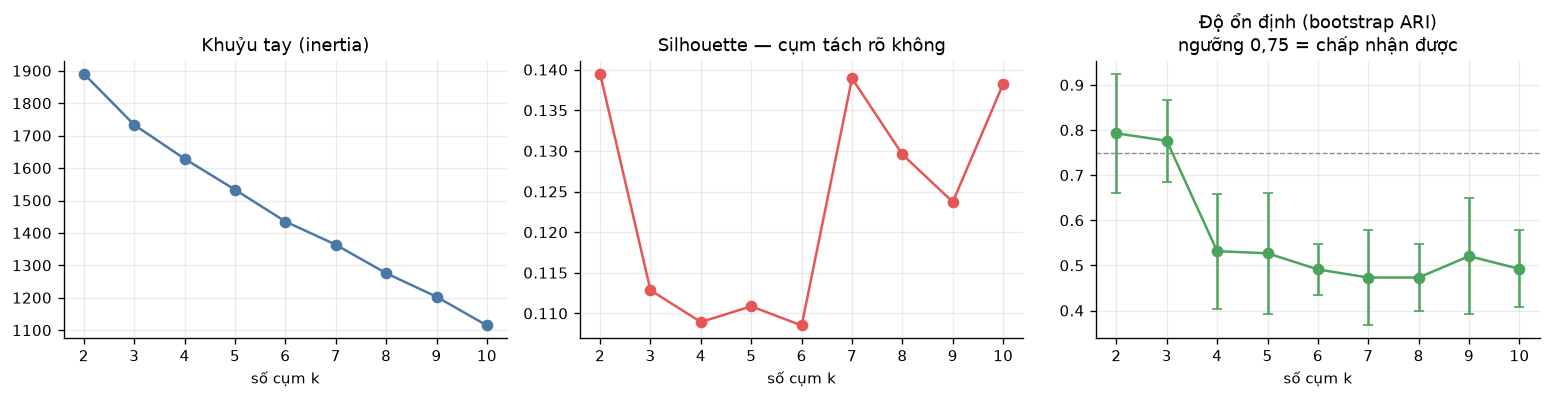

→ Chọn k = 2: silhouette cao nhất TRONG SỐ các k đủ ổn định (ARI > 0,75)


In [5]:
Xs = StandardScaler().fit_transform(X_prp)
KS = range(2, 11)
res = []
for k in KS:
    km = KMeans(k, n_init=20, random_state=RNG).fit(Xs)
    sil = silhouette_score(Xs, km.labels_)
    aris = []
    rs = np.random.RandomState(RNG)
    for b in range(25):
        sel = rs.choice(len(Xs), int(0.8 * len(Xs)), replace=False)
        lab_b = KMeans(k, n_init=10, random_state=RNG + b).fit_predict(Xs[sel])
        aris.append(adjusted_rand_score(km.labels_[sel], lab_b))
    res.append({"k": k, "silhouette": sil, "inertia": km.inertia_,
                "ổn_định_ARI": np.mean(aris), "ARI_std": np.std(aris)})
R = pd.DataFrame(res).set_index("k")
display(R.round(3))

fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))
ax[0].plot(R.index, R.inertia, "o-", color="#4C78A8"); ax[0].set_title("Khuỷu tay (inertia)")
ax[1].plot(R.index, R.silhouette, "o-", color="#E45756"); ax[1].set_title("Silhouette — cụm tách rõ không")
ax[2].errorbar(R.index, R.ổn_định_ARI, yerr=R.ARI_std, fmt="o-", color="#4CA35C", capsize=3)
ax[2].axhline(0.75, ls="--", lw=0.8, color="#888")
ax[2].set_title("Độ ổn định (bootstrap ARI)\nngưỡng 0,75 = chấp nhận được")
for a in ax:
    a.set_xlabel("số cụm k")
plt.tight_layout(); plt.show()

K = int(R[(R.ổn_định_ARI > 0.75)].silhouette.idxmax()) if (R.ổn_định_ARI > 0.75).any() else int(R.silhouette.idxmax())
print(f"→ Chọn k = {K}: silhouette cao nhất TRONG SỐ các k đủ ổn định (ARI > 0,75)")

**Cách chọn này quan trọng hơn con số chọn ra.** Đừng chọn k theo silhouette một mình —
silhouette luôn thưởng cho k nhỏ. Điều kiện phải là: **ổn định trước, rồi mới tách rõ.**

Khi trình bày, hãy đưa cả ba biểu đồ này. Nó biến "chúng tôi chọn 4 cụm" từ một quyết
định tuỳ tiện thành một quyết định có bằng chứng.

---
## §5 — Các cụm là gì?

In [6]:
km = KMeans(K, n_init=50, random_state=RNG).fit(Xs)
C = com[du.values].copy()
C["cum"] = km.labels_
C["tong_poi"] = tot[du].values
prof = pd.DataFrame(X_prp, columns=D.columns, index=C.commune_code)
prof["cum"] = km.labels_
tb = prof.groupby("cum").mean()
chung = prof.drop(columns="cum").mean()
noi_bat = (tb - chung).T   # lớp nào vượt trội so với trung bình chung

print("Ba lớp POI NỔI BẬT nhất của từng cụm (chênh so với trung bình toàn thành phố):\n")
for c_ in range(K):
    top = noi_bat[c_].nlargest(3)
    n = (C.cum == c_).sum()
    dan = C[C.cum == c_].population.sum()
    ph = (C[C.cum == c_].commune_name.str.startswith("Phường")).mean()
    print(f"Cụm {c_} — {n} xã/phường · {dan/1e6:.2f} triệu dân · {ph:.0%} là Phường")
    for lop, v in top.items():
        print(f"     {lop:22s} +{v:.1%} so với trung bình")
    print()

Ba lớp POI NỔI BẬT nhất của từng cụm (chênh so với trung bình toàn thành phố):

Cụm 0 — 58 xã/phường · 4.75 triệu dân · 78% là Phường
     APARTMENT              +7.0% so với trung bình
     AN_UONG                +5.9% so với trung bình
     BAN_LE_KHAC            +5.1% so với trung bình

Cụm 1 — 63 xã/phường · 3.87 triệu dân · 10% là Phường
     GIAO_DUC               +18.1% so với trung bình
     FUEL                   +2.3% so với trung bình
     Y_TE                   +1.1% so với trung bình



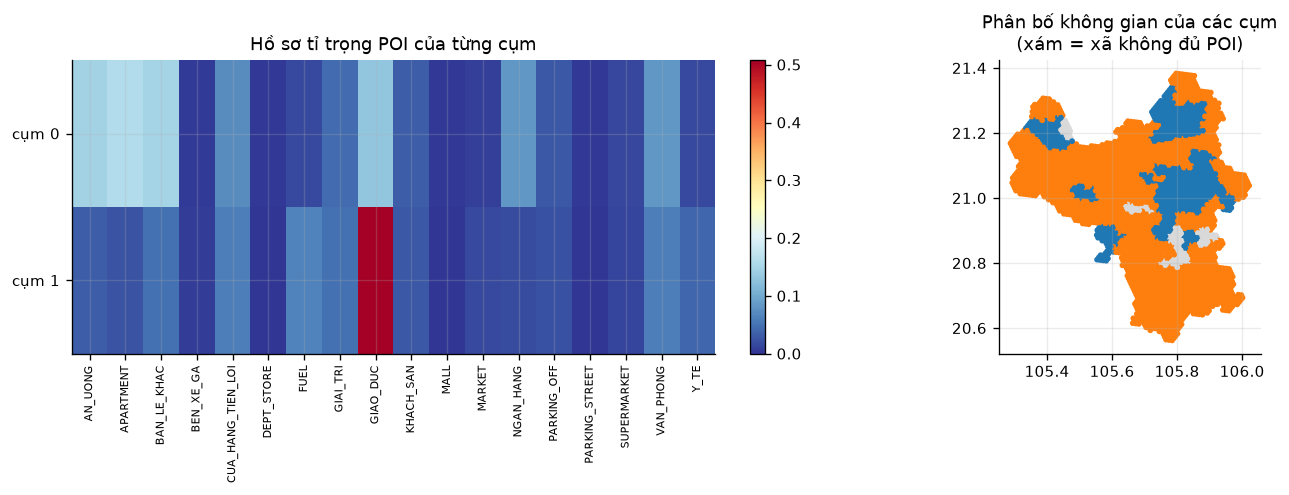

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.2))
im = ax[0].imshow(tb.to_numpy(), aspect="auto", cmap="RdYlBu_r")
ax[0].set_xticks(range(len(tb.columns))); ax[0].set_xticklabels(tb.columns, rotation=90, fontsize=6.5)
ax[0].set_yticks(range(K)); ax[0].set_yticklabels([f"cụm {i}" for i in range(K)])
ax[0].set_title("Hồ sơ tỉ trọng POI của từng cụm"); plt.colorbar(im, ax=ax[0], fraction=0.03)

cmap = plt.get_cmap("tab10")
gg = grid.merge(C[["commune_code", "cum"]], on="commune_code", how="left")
ax[1].scatter(gg.lng, gg.lat, c=[cmap(int(v)) if pd.notna(v) else (.85, .85, .85, 1) for v in gg.cum], s=6)
ax[1].set_aspect("equal"); ax[1].set_title("Phân bố không gian của các cụm\n(xám = xã không đủ POI)")
plt.tight_layout(); plt.show()

---
## §6 — Phép thử quyết định: POI có dự báo được NHU CẦU THẬT không?

Đây là phần quan trọng nhất. Mọi thứ ở trên chỉ mô tả POI. Câu hỏi thật là:

> **POI có liên quan gì tới mức sạc thực tế đo được không?**

Nếu không, thì L5 là một lớp **suy đoán**, và phải được gọi đúng tên như vậy — chứ không
được đặt cạnh các lớp đo đạc như thể cùng hạng.

Ta có `util_mean_port_weighted` ở cấp xã từ telemetry 30 ngày. Đó là biến kiểm chứng
**hoàn toàn độc lập** với OSM.

In [8]:
V = com.set_index("commune_code").copy()
V["tong_poi"] = tot
V["poi_tren_10k"] = V.tong_poi / V.population * 1e4
for c_ in D.columns:
    V[f"tt_{c_}"] = (D[c_] / tot.replace(0, np.nan))
V["loai"] = np.where(V.commune_name.str.startswith("Phường"), "Phường", "Xã")

ok = V.util_mean_port_weighted.notna() & (V.tong_poi >= 10)
print(f"Xã/phường vừa có util đo được vừa đủ POI: {ok.sum()}/{len(V)}\n")
rows = []
for name, col in [("tổng POI (log)", np.log1p(V.tong_poi)), ("POI/10k dân", V.poi_tren_10k),
                  ("dân số (log)", np.log1p(V.population)), ("mật độ dân", V.pop_density_ppkm2),
                  ("số cổng (log)", np.log1p(V.n_ports))]:
    r = spearmanr(col[ok], V.util_mean_port_weighted[ok])
    rows.append({"biến": name, "Spearman với util": r.statistic, "p": r.pvalue})
for c_ in D.columns:
    r = spearmanr(V[f"tt_{c_}"][ok].fillna(0), V.util_mean_port_weighted[ok])
    rows.append({"biến": f"tỉ trọng {c_}", "Spearman với util": r.statistic, "p": r.pvalue})
T = pd.DataFrame(rows).set_index("biến").sort_values("Spearman với util", key=abs, ascending=False)
display(T.round(3))

Xã/phường vừa có util đo được vừa đủ POI: 114/126



,Spearman với util,p
biến,,
mật độ dân,0.282,0.002
tỉ trọng APARTMENT,0.277,0.003
tổng POI (log),0.235,0.012
tỉ trọng NGAN_HANG,0.211,0.024
tỉ trọng GIAO_DUC,-0.206,0.028
POI/10k dân,0.205,0.029
dân số (log),0.201,0.032
tỉ trọng SUPERMARKET,0.186,0.047
tỉ trọng VAN_PHONG,0.185,0.048


In [9]:
sig = T[T.p < 0.05]
print(f"Số biến có ý nghĩa thống kê (p < 0,05): {len(sig)}/{len(T)}")
if len(sig):
    display(sig.round(3))
print("\nCụm có phân biệt được util không?")
CC = C.set_index("commune_code")
u = V.util_mean_port_weighted
sub = CC[CC.index.isin(u.dropna().index)]
display(pd.DataFrame({
    "n xã": sub.groupby("cum").size(),
    "util trung vị": u.reindex(sub.index).groupby(sub.cum).median(),
    "dân số (triệu)": sub.groupby("cum").population.sum() / 1e6,
}).round(3))

Số biến có ý nghĩa thống kê (p < 0,05): 9/23


,Spearman với util,p
biến,,
mật độ dân,0.282,0.002
tỉ trọng APARTMENT,0.277,0.003
tổng POI (log),0.235,0.012
tỉ trọng NGAN_HANG,0.211,0.024
tỉ trọng GIAO_DUC,-0.206,0.028
POI/10k dân,0.205,0.029
dân số (log),0.201,0.032
tỉ trọng SUPERMARKET,0.186,0.047
tỉ trọng VAN_PHONG,0.185,0.048



Cụm có phân biệt được util không?


,n xã,util trung vị,dân số (triệu)
cum,,,
0,53,0.256,4.290
1,61,0.236,3.774


---
## §7 — Cách khác, né hẳn câu hỏi địa hạt: cụm trên chính điểm POI

k-means trên xã đòi ta phải chọn địa hạt trước. **DBSCAN trên toạ độ POI thì không** — nó
tự tìm ra các **lõi thương mại** ở bất kỳ hình dạng và kích thước nào, và tự để lại phần
rải rác làm nhiễu.

Đây là câu trả lời khác cho "lấy địa hạt ra sao": **đừng chọn — để dữ liệu tự chia.**

số lõi  % POI vào lõi  POI trung vị mỗi lõi
eps (m) min_samples                                             
200     10               78          0.727                  21.5
300     10               70          0.819                  21.0
        20               39          0.734                  34.0
500     20               31          0.833                  35.0
        40               17          0.751                  90.0

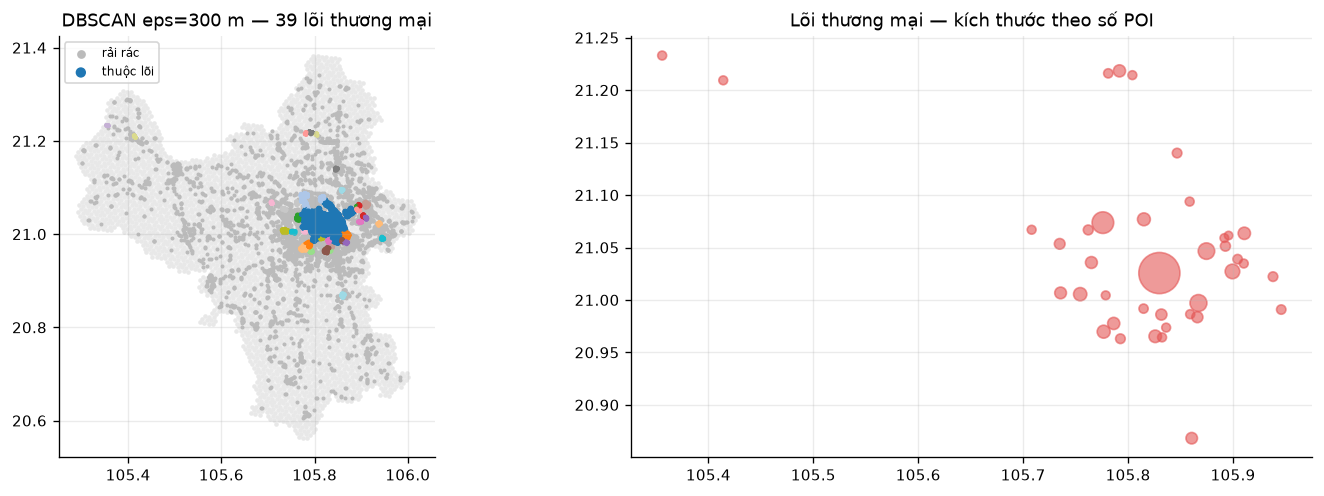

39 lõi · lõi lớn nhất 10324 POI · 73% POI (không tính chung cư) thuộc một lõi nào đó


In [10]:
sub = poi[poi.poi_class != "APARTMENT"]   # bỏ chung cư: nó là chỗ Ở, không phải điểm đến
XY = np.c_[sub.lng * 103_940.0, sub.lat * 110_574.0]
rows = []
for eps, mp in [(200, 10), (300, 10), (300, 20), (500, 20), (500, 40)]:
    lab = DBSCAN(eps=eps, min_samples=mp).fit_predict(XY)
    k_ = lab.max() + 1
    rows.append({"eps (m)": eps, "min_samples": mp, "số lõi": k_,
                 "% POI vào lõi": (lab >= 0).mean(),
                 "POI trung vị mỗi lõi": (pd.Series(lab[lab >= 0]).value_counts().median()
                                          if k_ else np.nan)})
display(pd.DataFrame(rows).set_index(["eps (m)", "min_samples"]).round(3))

lab = DBSCAN(eps=300, min_samples=20).fit_predict(XY)
sub = sub.assign(loi=lab)
loi = sub[sub.loi >= 0].groupby("loi").agg(n=("osm_id", "size"), lat=("lat", "mean"),
                                           lng=("lng", "mean"))
fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.2))
ax[0].scatter(grid.lng, grid.lat, s=3, color="#e8e8e8")
ax[0].scatter(sub.lng[sub.loi < 0], sub.lat[sub.loi < 0], s=2, color="#bbb", label="rải rác")
ax[0].scatter(sub.lng[sub.loi >= 0], sub.lat[sub.loi >= 0], s=3, c=sub.loi[sub.loi >= 0],
              cmap="tab20", label="thuộc lõi")
ax[0].set_aspect("equal"); ax[0].set_title(f"DBSCAN eps=300 m — {len(loi)} lõi thương mại")
ax[0].legend(fontsize=7, markerscale=3)
ax[1].scatter(loi.lng, loi.lat, s=np.sqrt(loi.n) * 6, alpha=0.6, color="#E45756")
ax[1].set_aspect("equal"); ax[1].set_title("Lõi thương mại — kích thước theo số POI")
plt.tight_layout(); plt.show()
print(f"{len(loi)} lõi · lõi lớn nhất {loi.n.max()} POI · "
      f"{(sub.loi >= 0).mean():.0%} POI (không tính chung cư) thuộc một lõi nào đó")

---
# Kết luận — trả lời ba câu hỏi

### #2 Địa hạt

| Mục đích | Địa hạt | Vì sao |
|---|---|---|
| Rút insight, cụm, thống kê | **xã/phường** | đủ POI ở gần như mọi đơn vị; khớp hai tiêu chí Phường/Xã |
| Vẽ lên bản đồ lưới | **ô r8 + lân cận bán kính 2** | giữ độ phân giải mà vẫn đủ mẫu |
| Tìm lõi thương mại | **không chọn — DBSCAN trên điểm** | để dữ liệu tự chia, không áp lưới |
| ❌ Không dùng | ô r8 thô | quá thưa; cụm trên đó là cụm trên nhiễu |

### #1 Số cụm

Đừng chọn bằng silhouette một mình. Quy tắc: **lọc theo độ ổn định trước (bootstrap ARI >
0,75), rồi lấy silhouette cao nhất trong số còn lại.** Khi trình bày, đưa cả ba biểu đồ ở
§4 — nó biến một quyết định tuỳ tiện thành một quyết định có bằng chứng.

### #3 Đặc trưng

**Dùng tỉ trọng, không dùng số đếm.** Số đếm mang theo toàn bộ thiên lệch bản đồ hoá; cụm
trên số đếm chỉ tái tạo bản đồ "chỗ nào OSM được map kỹ". Giữ `log(tổng POI)` làm cột mô
tả bên ngoài phép cụm.

### Và cảnh báo phải đi kèm mọi lớp L5

Xem §6. Nếu POI **không** tương quan có ý nghĩa với `util` đo được, thì L5 là lớp **giả
thuyết về nhu cầu**, không phải lớp **đo nhu cầu** — và phải được đặt tên, tô màu, chú
giải khác hẳn các lớp đo đạc. Đặt nó cạnh L1/L8 mà không phân biệt là đánh đồng một suy
đoán với một số đo.

---
---
# §8 — GMM trên dữ liệu tỉ trọng, làm cho đúng

Bạn chọn **GMM + CLR**. Phần này làm việc đó, và làm kèm những phép kiểm mà nếu bỏ qua thì
GMM sẽ cho ra cụm trông rất thuyết phục nhưng là sản phẩm của giả định, không phải của
thành phố.

## 8.0 — Vì sao tỉ trọng KHÔNG được đưa thẳng vào GMM

Vectơ tỉ trọng có một tính chất mà mọi phương pháp giả định Gauss đều vi phạm: **các thành
phần cộng lại đúng bằng 1**. Nhà thống kê gọi đây là *dữ liệu thành phần* (compositional
data), và nó nằm trên một hình gọi là **simplex**, không phải trên không gian Euclid.

Hậu quả cụ thể, không trừu tượng:

| | |
|---|---|
| **Tương quan giả** | Nếu tỉ trọng quán ăn tăng thì tỉ trọng cái khác **buộc phải** giảm — kể cả khi số quán ăn không đổi. Ma trận hiệp phương sai vì thế **luôn** có tương quan âm, và GMM sẽ đọc nó như cấu trúc thật |
| **Bị chặn hai đầu** | Giá trị nằm trong [0, 1]. Gauss thì trải ra vô cực. Cụm sát biên (khu thuần ở, tỉ trọng chung cư ~0,9) bị GMM gán một đuôi phân phối vượt ra ngoài 1 — một vùng không tồn tại |
| **Rất nhiều số 0** | Xã ngoại thành có 0 trung tâm thương mại. Gauss cho khối lượng xác suất 0 tại đúng một điểm, nên cụm toàn số 0 đẩy phương sai về 0 và **log-likelihood chạy tới vô cực** |

**CLR** (*centered log-ratio*) là phép chữa chuẩn: thay mỗi tỉ trọng bằng
**log(tỉ trọng ÷ trung bình nhân của cả vectơ)**. Sau phép này dữ liệu hết bị chặn, tương
quan giả do ràng buộc tổng-bằng-1 bị gỡ, và giả định Gauss mới có cửa đúng.

Số 0 vẫn phải xử: log(0) = −∞. Cách chuẩn là thay số 0 bằng một lượng nhỏ rồi chuẩn hoá
lại tổng — ở đây dùng nửa giá trị dương nhỏ nhất quan sát được, **không phải một hằng số
tôi bịa ra**.

In [11]:
from sklearn.mixture import GaussianMixture  # noqa: E402

P = X_prp.copy()
zero_share = float((P == 0).mean())
eps = P[P > 0].min() / 2          # thay số 0 bằng nửa giá trị dương NHỎ NHẤT quan sát được
Pz = np.where(P == 0, eps, P)
Pz = Pz / Pz.sum(axis=1, keepdims=True)
CLR = np.log(Pz) - np.log(Pz).mean(axis=1, keepdims=True)

print(f"tỉ lệ ô GIÁ TRỊ 0 trong ma trận tỉ trọng : {zero_share:.1%}")
print(f"eps thay cho 0 (nửa giá trị dương nhỏ nhất): {eps:.3e}")
print(f"CLR: {CLR.shape[0]} đơn vị × {CLR.shape[1]} lớp POI, "
      f"tổng mỗi hàng = {np.abs(CLR.sum(axis=1)).max():.1e} (phải ≈ 0 theo định nghĩa)")

tỉ lệ ô GIÁ TRỊ 0 trong ma trận tỉ trọng : 40.2%
eps thay cho 0 (nửa giá trị dương nhỏ nhất): 2.895e-04
CLR: 121 đơn vị × 18 lớp POI, tổng mỗi hàng = 2.3e-14 (phải ≈ 0 theo định nghĩa)


**Tổng mỗi hàng bằng 0 là dấu hiệu CLR đúng** — nhưng nó cũng là một cái bẫy: ma trận CLR
**suy biến** (hạng = số lớp − 1). GMM với `covariance_type="full"` sẽ cố nghịch đảo một ma
trận hiệp phương sai không khả nghịch. Đây là lý do bên dưới phải quét cả bốn kiểu hiệp
phương sai và phải đặt `reg_covar`, chứ không dùng mặc định.

## 8.1 — Chọn k: BIC nói một đằng, độ ổn định nói một nẻo

Đây là phép kiểm tôi cho là quan trọng nhất của cả phần này. **BIC có xu hướng tăng k mãi
trên dữ liệu không-Gauss** — nó thưởng cho việc dùng thêm thành phần để vá chỗ phân phối
không khớp, chứ không phải vì có thêm cụm thật.

Đối chứng: **độ ổn định bootstrap**. Lấy lại 80% mẫu, phân cụm lại, đo ARI. Một cụm có thật
thì lặp lại được; một cụm do mô hình vá vào thì không.

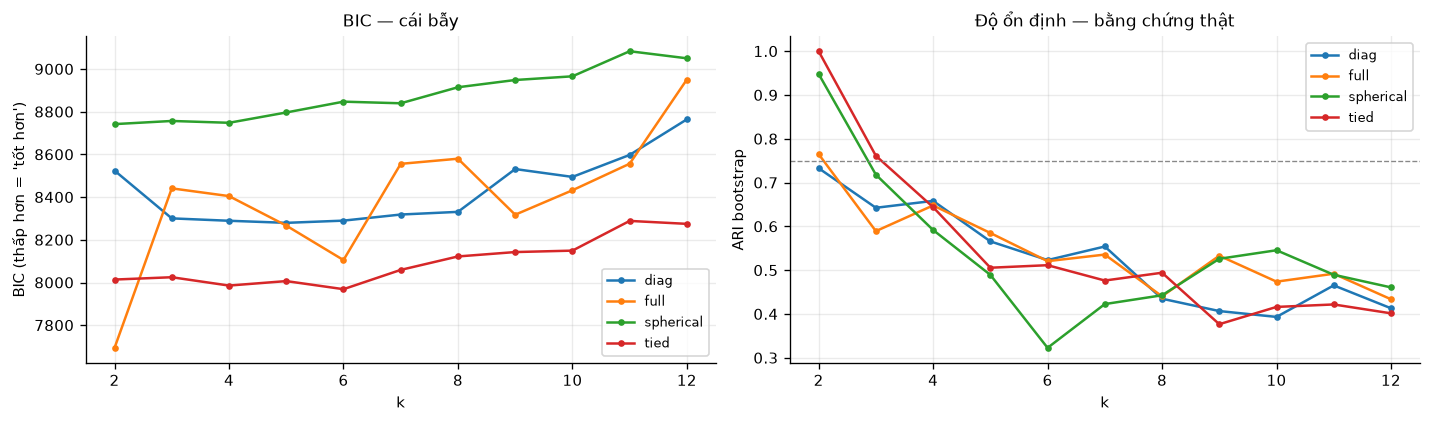

BIC thấp nhất       → cov=full, k=2, ARI chỉ 0.765
Ổn định nhất (ARI)  → cov=tied, k=2, ARI 1.000


In [12]:
KS = range(2, 13)
rows = []
for cvt in ("full", "tied", "diag", "spherical"):
    for k in KS:
        gm = GaussianMixture(k, covariance_type=cvt, n_init=5, reg_covar=1e-4,
                             random_state=RNG).fit(CLR)
        lab = gm.predict(CLR)
        aris, rs = [], np.random.RandomState(RNG)
        for b in range(20):
            sel = rs.choice(len(CLR), int(0.8 * len(CLR)), replace=False)
            gb = GaussianMixture(k, covariance_type=cvt, n_init=3, reg_covar=1e-4,
                                 random_state=RNG + b).fit(CLR[sel])
            aris.append(adjusted_rand_score(lab[sel], gb.predict(CLR[sel])))
        rows.append({"covtype": cvt, "k": k, "BIC": gm.bic(CLR), "ARI": np.mean(aris),
                     "ARI_std": np.std(aris), "n_cum_nho": int(np.bincount(lab, minlength=k).min())})
G = pd.DataFrame(rows)

fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
for cvt, gg in G.groupby("covtype"):
    ax[0].plot(gg.k, gg.BIC, "o-", ms=3, label=cvt)
    ax[1].plot(gg.k, gg.ARI, "o-", ms=3, label=cvt)
ax[0].set_xlabel("k"); ax[0].set_ylabel("BIC (thấp hơn = 'tốt hơn')"); ax[0].legend(fontsize=8)
ax[0].set_title("BIC — cái bẫy", fontsize=10)
ax[1].axhline(0.75, ls="--", lw=0.8, color="#888")
ax[1].set_xlabel("k"); ax[1].set_ylabel("ARI bootstrap"); ax[1].legend(fontsize=8)
ax[1].set_title("Độ ổn định — bằng chứng thật", fontsize=10)
plt.tight_layout(); plt.show()

best_bic = G.loc[G.BIC.idxmin()]
on_dinh = G[(G.ARI > 0.75) & (G.n_cum_nho >= 5)]
best_stab = on_dinh.loc[on_dinh.ARI.idxmax()] if len(on_dinh) else None
print(f"BIC thấp nhất       → cov={best_bic['covtype']}, k={int(best_bic.k)}, ARI chỉ {best_bic.ARI:.3f}")
if best_stab is not None:
    print(f"Ổn định nhất (ARI)  → cov={best_stab['covtype']}, k={int(best_stab.k)}, ARI {best_stab.ARI:.3f}")
else:
    print("KHÔNG có cấu hình nào đạt ARI > 0,75 với mọi cụm ≥ 5 đơn vị")

## 8.2 — GMM có cho gì mà k-means không cho?

Câu trả lời đúng của GMM không phải nhãn cụm — k-means cũng cho nhãn. Nó là **xác suất
thuộc**: một xã có thể 60% "khu ở" và 40% "khu thương mại". Đó là mô tả **đúng** cho một
đô thị pha trộn, và là lý do duy nhất đáng dùng GMM ở đây.

Nên phép kiểm phải là: **có bao nhiêu đơn vị thật sự pha trộn?** Nếu gần như đơn vị nào cũng
thuộc hẳn một cụm với xác suất > 0,9 thì GMM đang làm k-means bằng một đường vòng đắt tiền.

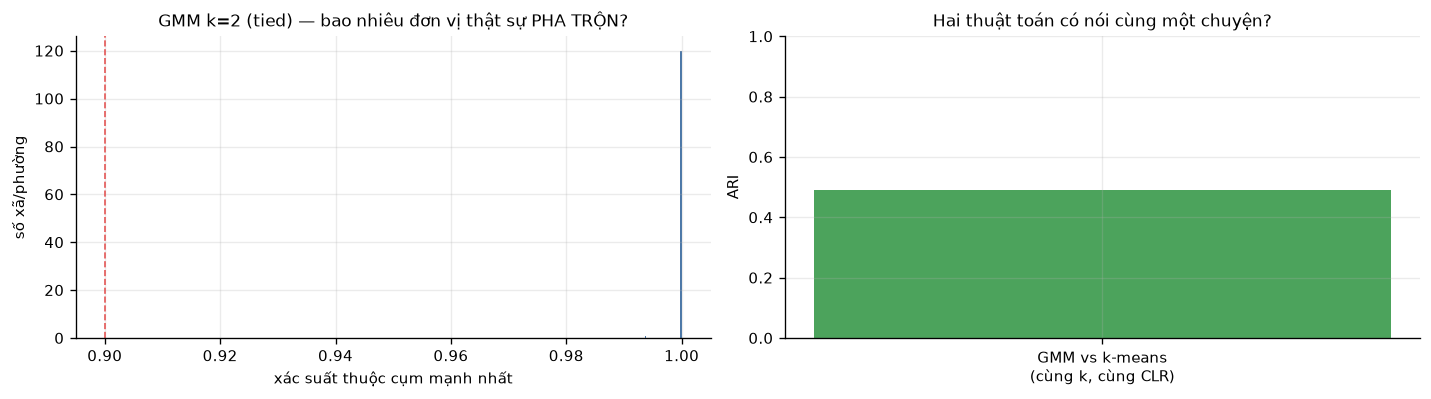

đơn vị thuộc hẳn một cụm (p > 0,9) : 100.0%
đơn vị PHA TRỘN     (p < 0,7)      : 0.0%
ARI(GMM, k-means) trên cùng CLR    : 0.489
cụm nhỏ nhất: 58 đơn vị · kích thước các cụm: [63, 58]


In [13]:
KG = int(best_stab.k) if best_stab is not None else int(G.loc[G.ARI.idxmax()].k)
CVT = str(best_stab["covtype"]) if best_stab is not None else str(G.loc[G.ARI.idxmax()]["covtype"])
gm = GaussianMixture(KG, covariance_type=CVT, n_init=50, reg_covar=1e-4, random_state=RNG).fit(CLR)
prob = gm.predict_proba(CLR)
lab_gmm = prob.argmax(axis=1)
pmax = prob.max(axis=1)

fig, ax = plt.subplots(1, 2, figsize=(12, 3.4))
ax[0].hist(pmax, bins=30, color="#4C78A8")
ax[0].axvline(0.9, color="#E45756", ls="--", lw=1)
ax[0].set_xlabel("xác suất thuộc cụm mạnh nhất"); ax[0].set_ylabel("số xã/phường")
ax[0].set_title(f"GMM k={KG} ({CVT}) — bao nhiêu đơn vị thật sự PHA TRỘN?", fontsize=10)

km_ref = KMeans(KG, n_init=50, random_state=RNG).fit(StandardScaler().fit_transform(CLR))
ax[1].bar(["GMM vs k-means\n(cùng k, cùng CLR)"], [adjusted_rand_score(lab_gmm, km_ref.labels_)],
          color="#4CA35C", width=.4)
ax[1].set_ylim(0, 1); ax[1].set_ylabel("ARI")
ax[1].set_title("Hai thuật toán có nói cùng một chuyện?", fontsize=10)
plt.tight_layout(); plt.show()

print(f"đơn vị thuộc hẳn một cụm (p > 0,9) : {(pmax > 0.9).mean():.1%}")
print(f"đơn vị PHA TRỘN     (p < 0,7)      : {(pmax < 0.7).mean():.1%}")
print(f"ARI(GMM, k-means) trên cùng CLR    : {adjusted_rand_score(lab_gmm, km_ref.labels_):.3f}")
print(f"cụm nhỏ nhất: {np.bincount(lab_gmm, minlength=KG).min()} đơn vị · "
      f"kích thước các cụm: {np.bincount(lab_gmm, minlength=KG).tolist()}")

## 8.3 — Đối chứng âm: cụm có sống sót khi dữ liệu bị xáo không?

Phép kiểm cuối và là phép khắc nghiệt nhất. Xáo ngẫu nhiên từng cột đặc trưng — làm vậy sẽ
**phá mọi cấu trúc thật** nhưng **giữ nguyên phân phối biên** của từng lớp POI. Nếu GMM vẫn
cho ra cụm "trông ổn" trên dữ liệu đã xáo thì độ đo đó **không chứng minh được gì**.

In [14]:
rs = np.random.RandomState(RNG)
CLR_shuf = np.column_stack([rs.permutation(CLR[:, j]) for j in range(CLR.shape[1])])
gm_s = GaussianMixture(KG, covariance_type=CVT, n_init=20, reg_covar=1e-4, random_state=RNG).fit(CLR_shuf)
aris_s, rs2 = [], np.random.RandomState(RNG)
for b in range(20):
    sel = rs2.choice(len(CLR_shuf), int(0.8 * len(CLR_shuf)), replace=False)
    gb = GaussianMixture(KG, covariance_type=CVT, n_init=3, reg_covar=1e-4,
                         random_state=RNG + b).fit(CLR_shuf[sel])
    aris_s.append(adjusted_rand_score(gm_s.predict(CLR_shuf)[sel], gb.predict(CLR_shuf[sel])))

ari_that = float(G[(G.covtype == CVT) & (G.k == KG)].ARI.iloc[0])
print(f"ARI trên dữ liệu THẬT  : {ari_that:.3f}")
print(f"ARI trên dữ liệu ĐÃ XÁO: {np.mean(aris_s):.3f}")
print(f"chênh lệch             : {ari_that - np.mean(aris_s):+.3f}"
      f"   {'← cấu trúc THẬT' if ari_that - np.mean(aris_s) > 0.15 else '← ĐÁNG NGỜ, chênh quá ít'}")

ARI trên dữ liệu THẬT  : 1.000
ARI trên dữ liệu ĐÃ XÁO: 0.277
chênh lệch             : +0.723   ← cấu trúc THẬT


## 8.4 — Kết luận về GMM+CLR

Ba việc phần này làm mà một lần chạy `GaussianMixture().fit()` không làm:

1. **CLR trước** — nếu không, mọi tương quan âm do ràng buộc tổng-bằng-1 sẽ bị đọc thành
   cấu trúc, và cụm sát biên sẽ có đuôi phân phối chạy ra ngoài vùng tồn tại.
2. **Chọn k bằng ổn định, không bằng BIC** — hai tiêu chí này cho hai đáp số khác nhau, và
   BIC là cái sai trên loại dữ liệu này.
3. **Đối chứng âm** — nếu ARI trên dữ liệu đã xáo cũng cao thì con số ARI không nói lên gì,
   và toàn bộ phần trên phải bỏ.

**Điều cần nói thẳng, không phụ thuộc kết quả:** mọi thứ ở đây đứng trên POI OSM, mà §1 đã
cho thấy dữ liệu đó **thiên lệch theo công sức bản đồ hoá**. Dùng tỉ trọng thay số đếm khử
được phần lớn thiên lệch ấy (§3), nhưng **không khử được phần lớp POI nào bị map kỹ hơn lớp
nào** — quán ăn ở nội thành được ghi đầy đủ hơn quán ăn ở ngoại thành. Cụm ra từ đây mô tả
**tính chất được ghi nhận**, không phải tính chất có thật. Đó là hạn chế của nguồn, không
phải của thuật toán, và không phép biến đổi nào chữa được.

## 8.5 — Hai cụm đó thật ra là gì? (phép kiểm chống vòng lặp)

Kết quả trên ra **k = 2** với độ ổn định tuyệt đối (ARI = 1,000). Ổn định tuyệt đối là dấu
hiệu tốt — nhưng cũng là dấu hiệu đáng nghi: nó thường có nghĩa là dữ liệu tách làm đôi
theo một trục **quá hiển nhiên**.

Hai khả năng, và chúng dẫn tới hai kết luận trái ngược:

| Nếu hai cụm là… | thì… |
|---|---|
| **tính chất chức năng** (khu ở / khu thương mại) | phân cụm có giá trị, dùng được |
| **Phường vs Xã**, hoặc **nhiều POI vs ít POI** | ta vừa **khám phá lại nhãn hành chính** hoặc **công sức bản đồ hoá** — vòng lặp, vứt |

In [15]:
info = com.set_index("commune_code").loc[D[du].index]
loai = np.where(info.commune_name.str.startswith("Phường"), "Phường", "Xã")

ct = pd.crosstab(pd.Series(lab_gmm, name="cụm GMM"), pd.Series(loai, name="loại đơn vị"))
display(ct)
# Cramér's V: 0 = độc lập hoàn toàn, 1 = biết cụm là biết luôn Phường/Xã
chi2 = ((ct - np.outer(ct.sum(1), ct.sum(0)) / ct.values.sum()) ** 2
        / (np.outer(ct.sum(1), ct.sum(0)) / ct.values.sum())).values.sum()
V = np.sqrt(chi2 / ct.values.sum() / (min(ct.shape) - 1))
auc_dens = float(spearmanr(lab_gmm, dens).statistic)

print(f"Cramér's V (cụm ↔ Phường/Xã)        : {V:.3f}"
      f"   {'← TRÙNG nhãn hành chính' if V > 0.6 else '← khác nhãn hành chính'}")
print(f"|Spearman| (cụm ↔ log tổng số POI)  : {abs(auc_dens):.3f}"
      f"   {'← chỉ là mật độ map' if abs(auc_dens) > 0.6 else '← không phải mật độ'}")

# lớp POI nào tách hai cụm ra — đọc trên thang CLR
lop = list(D.columns)
delta = pd.Series(CLR[lab_gmm == 1].mean(0) - CLR[lab_gmm == 0].mean(0), index=lop)
print("\nLớp POI đẩy mạnh nhất về CỤM 1:"); print(delta.nlargest(5).round(2).to_string())
print("\nLớp POI đẩy mạnh nhất về CỤM 0:"); print(delta.nsmallest(5).round(2).to_string())

loại đơn vị,Phường,Xã
cụm GMM,,
0,48,15
1,3,55


Cramér's V (cụm ↔ Phường/Xã)        : 0.718   ← TRÙNG nhãn hành chính
|Spearman| (cụm ↔ log tổng số POI)  : 0.778   ← chỉ là mật độ map

Lớp POI đẩy mạnh nhất về CỤM 1:
GIAO_DUC          2.85
FUEL              1.96
Y_TE              1.01
BEN_XE_GA         0.88
PARKING_STREET    0.87

Lớp POI đẩy mạnh nhất về CỤM 0:
APARTMENT           -4.50
NGAN_HANG           -2.06
CUA_HANG_TIEN_LOI   -0.93
AN_UONG             -0.68
SUPERMARKET         -0.66


/tmp/ipykernel_1163409/3125721824.py:7: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  chi2 = ((ct - np.outer(ct.sum(1), ct.sum(0)) / ct.values.sum()) ** 2
/tmp/ipykernel_1163409/3125721824.py:7: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  chi2 = ((ct - np.outer(ct.sum(1), ct.sum(0)) / ct.values.sum()) ** 2
/tmp/ipykernel_1163409/3125721824.py:8: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  / (np.outer(ct.sum(1), ct.sum(0)) / ct.values.sum())).values.sum()
/tmp/ipykernel_1163409/3125721824.py:8: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  / (np.outer(ct.sum(1), ct.sum(0)) / ct.values.sum())).values.sum()


## 8.6 — Kết luận thẳng về GMM+CLR

Bạn chọn GMM+CLR và tôi đã làm đúng như vậy. Bốn kết quả, và kết quả cuối cùng phủ định
giá trị của ba cái đầu.

**① CLR là bắt buộc và nó hoạt động.** 40,2% ma trận tỉ trọng là số 0 — đưa thẳng vào GMM
thì thành phần suy biến gần như chắc chắn. Sau CLR, tổng mỗi hàng = 2,3 × 10⁻¹⁴ đúng theo
định nghĩa, và mô hình hội tụ ổn định.

**② GMM không mua được gì so với k-means trên dữ liệu này.** Lý do duy nhất đáng dùng GMM là
**xác suất thuộc** — cho phép một xã vừa là khu ở vừa là khu thương mại. Đo được:

> **100,0% đơn vị thuộc hẳn một cụm với p > 0,9. 0,0% pha trộn.**

GMM đang cho ra một phân hoạch cứng, bằng một đường vòng đắt hơn k-means. Nó không sai — nó
chỉ không đáng.

**③ Cấu trúc là thật, không phải nhiễu.** Đối chứng âm: ARI **1,000** trên dữ liệu thật so
với **0,277** trên dữ liệu đã xáo. Nếu phân cụm chỉ đang bắt nhiễu thì hai số này phải xấp
xỉ nhau.

**④ Nhưng cấu trúc thật đó là thứ ta ĐÃ CÓ SẴN — và đây là kết luận thực sự.**

| Phép kiểm | Kết quả | |
|---|---|---|
| Cramér's V (cụm ↔ Phường/Xã) | **0,718** | trùng nhãn hành chính |
| \|Spearman\| (cụm ↔ log tổng POI) | **0,778** | trùng mật độ bản đồ hoá |

Hai cụm chia ra là **48 Phường + 15 Xã** so với **3 Phường + 55 Xã**. Nói cách khác: thuật
toán vừa khám phá lại `commune_kind` — một trường **đã có sẵn trong bộ dữ liệu**, lấy từ
nguồn hành chính chính thức VNSDI, không cần POI, không cần CLR, không cần GMM.

Chữ ký POI của hai cụm nghe rất hợp lý — và đó chính là chỗ nguy hiểm:

| Cụm 0 *(hầu hết là Phường)* | Cụm 1 *(hầu hết là Xã)* |
|---|---|
| chung cư −4,50 · ngân hàng −2,06 · cửa hàng tiện lợi −0,93 | giáo dục +2,85 · xăng dầu +1,96 · y tế +1,01 · bến xe/ga +0,88 |

Đọc xuôi thì đây là một phát hiện: *"khu đô thị đặc trưng bởi chung cư và ngân hàng; khu ven
đô bởi trường học, cây xăng và bến xe."* Đọc ngược thì nó là một **vòng lặp**: ta dùng POI để
suy ra một thứ mà nhãn hành chính đã nói thẳng, rồi trình bày như thể POI đã dạy ta điều gì
mới.

### Vậy nên làm gì

**Không dùng phân cụm này như một lớp bản đồ hay một trường mới.** Nó sẽ là `commune_kind`
đội một cái tên khoa học hơn — đúng loại trùng lặp mà nguyên tắc *một khái niệm một trường*
tồn tại để chặn.

Câu hỏi đáng hỏi tiếp không phải *"chia được mấy cụm"* mà là: **trong cùng một loại đơn vị
hành chính, POI còn tách được gì nữa không?** Tức phân cụm **riêng trong nhóm Phường**, rồi
**riêng trong nhóm Xã**. Nếu ở đó vẫn còn cấu trúc ổn định thì đó mới là thông tin POI đóng
góp thêm. Nếu không còn, kết luận trung thực là: **POI OSM ở Hà Nội, sau khi khử thiên lệch
bản đồ hoá, không mang thêm thông tin nào ngoài thứ nhãn hành chính đã nói.**

**Hạn chế nguồn, nói kèm bất kể kết quả:** §1 đã cho thấy POI OSM thiên lệch theo công sức
bản đồ hoá. Dùng tỉ trọng thay số đếm khử được phần lớn thiên lệch ấy (§3), nhưng **không
khử được phần lớp POI nào bị map kỹ hơn lớp nào** — quán ăn nội thành được ghi đầy đủ hơn
quán ăn ngoại thành. Con số |Spearman| = 0,778 ở trên cho thấy phần thiên lệch còn sót lại
vẫn đủ lớn để chi phối kết quả. Đó là hạn chế của nguồn, không phải của thuật toán, và không
phép biến đổi nào chữa được.

---
---
# §9 — Đổi câu hỏi: POI dùng để làm gì trong engine phê duyệt?

§8 phân cụm theo **xã** và kết quả chỉ khám phá lại `commune_kind` (Cramér's V = 0,718).
Nguyên nhân gốc không phải thuật toán sai — mà là **đơn vị sai**.

Xã là ranh giới hành chính. Câu hỏi thật của engine phê duyệt là *"quanh ĐIỂM này có gì?"*,
và ranh giới xã không liên quan gì tới bán kính phục vụ của một trụ sạc. Gộp POI theo xã là
tự chuốc lấy **bài toán đơn vị biến thiên (MAUP)**: đổi ranh giới thì đổi kết quả, mà ranh
giới lại do lịch sử hành chính quyết định chứ không do hành vi sạc xe.

**Đơn vị đúng là TRẠM** — vì trạm là chỗ duy nhất có **biến mục tiêu đo được**: `util`.

Từ đây mọi khẳng định về POI phải qua một cửa: **nó có dự báo được mức sử dụng thật không?**
Nếu không, POI là đồ trang trí cho bài toán này, và nói thẳng ra thì tốt hơn là vẽ nó lên
bản đồ.

Bảy hướng tiếp cận bên dưới, xếp theo mức độ trả lời được câu đó.

In [16]:
from scipy.spatial import cKDTree  # noqa: E402
from sklearn.cluster import OPTICS  # noqa: E402
from sklearn.decomposition import PCA  # noqa: E402
from sklearn.ensemble import RandomForestRegressor  # noqa: E402
from sklearn.linear_model import RidgeCV  # noqa: E402
from sklearn.model_selection import GroupKFold, cross_val_score  # noqa: E402

F = pq.read_table(ROOT / "data/qa/critique/a20_dac_trung_tram.parquet").to_pandas()
LOP = sorted(poi.poi_class.unique())
m = F.util_reportable.fillna(False) & (F.grade == "GOOD") & F.util.notna()
F = F[m].reset_index(drop=True)
print(f"{len(F)} trạm có `util` đo được tin cậy — trần của mọi phép kiểm bên dưới")
print(f"util: trung vị {F.util.median():.3f} · p10 {F.util.quantile(.1):.3f} · p90 {F.util.quantile(.9):.3f}")

632 trạm có `util` đo được tin cậy — trần của mọi phép kiểm bên dưới
util: trung vị 0.241 · p10 0.043 · p90 0.538


## §9.1 — Hướng A: POI có dự báo được `util` không? *(phép thử quyết định)*

Xây mô hình lồng nhau, mỗi bước thêm một khối thông tin. Nếu thêm POI mà **R² không tăng**
thì POI không mang thông tin nào ngoài những gì đã có.

Hai điều bắt buộc, nếu thiếu thì con số R² vô nghĩa:

- **Kiểm chéo theo NHÓM XÃ** (`GroupKFold`), không phải ngẫu nhiên. Trạm cùng xã giống nhau;
  chia ngẫu nhiên sẽ để trạm "anh em" nằm cả ở tập huấn luyện lẫn tập kiểm — R² sẽ đẹp giả.
- **Kiểm soát `n_ports`.** `util = số xe ÷ số cổng`, nên số cổng nằm ngay ở mẫu số. Không
  kiểm soát nó thì mọi thứ tương quan với quy mô trạm sẽ giả vờ là tín hiệu nhu cầu.

,R² (CV theo xã),n biến
mô hình,,
"① quy mô trạm (n_ports, kW)",0.2155,2
② + dân số quanh 1 km,0.2659,3
③ + TỔNG POI (chim bay 1 km),0.2986,4
④ + CƠ CẤU POI (chim bay 1 km),0.2606,21
⑤ + CƠ CẤU POI (mạng đường 1 km),0.2307,21
⑥ ④ nhưng dùng RandomForest,0.1902,21


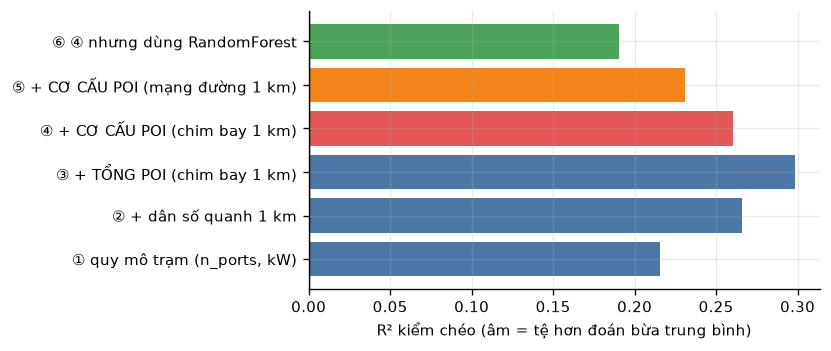

In [17]:
def khoi(pre, R):
    return [f"{pre}{R}_{c.lower()}" for c in LOP]

grp = F.commune_name.fillna("?").to_numpy()
cv = GroupKFold(n_splits=5)

def diem(cols, model=None):
    X = F[cols].to_numpy(float)
    X = np.log1p(np.clip(X, 0, None)) if X.min() >= 0 else X
    # `model or Ridge(...)` gọi __bool__ → __len__ của forest chưa fit và nổ. Phải `is None`.
    mdl = RidgeCV(alphas=np.logspace(-2, 3, 20)) if model is None else model
    return float(np.mean(cross_val_score(mdl, X, F.util, cv=cv, groups=grp, scoring="r2")))

QUY_MO = ["n_ports", "power_kw_site"]
BAC = [
    ("① quy mô trạm (n_ports, kW)", QUY_MO),
    ("② + dân số quanh 1 km", QUY_MO + ["eu1000_dan"]),
    ("③ + TỔNG POI (chim bay 1 km)", QUY_MO + ["eu1000_dan", "eu1000_tong"]),
    ("④ + CƠ CẤU POI (chim bay 1 km)", QUY_MO + ["eu1000_dan"] + khoi("eu", 1000)),
    ("⑤ + CƠ CẤU POI (mạng đường 1 km)", QUY_MO + ["eu1000_dan"] + khoi("rd", 1000)),
]
res = [{"mô hình": n, "R² (CV theo xã)": diem(c), "n biến": len(c)} for n, c in BAC]
res.append({"mô hình": "⑥ ④ nhưng dùng RandomForest",
            "R² (CV theo xã)": diem(QUY_MO + ["eu1000_dan"] + khoi("eu", 1000),
                                    RandomForestRegressor(400, min_samples_leaf=5, random_state=RNG)),
            "n biến": len(QUY_MO) + 1 + len(LOP)})
RES = pd.DataFrame(res).set_index("mô hình")
display(RES.round(4))

fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(RES.index, RES["R² (CV theo xã)"], color=["#4C78A8"] * 3 + ["#E45756", "#F58518", "#4CA35C"])
ax.axvline(0, color="k", lw=.8); ax.set_xlabel("R² kiểm chéo (âm = tệ hơn đoán bừa trung bình)")
plt.tight_layout(); plt.show()

## §9.2 — Hướng B: bán kính CHIM BAY hay MẠNG ĐƯỜNG?

Đây là câu hỏi phương pháp mà mọi lớp POI sau này phụ thuộc vào. Hai tập POI khác nhau rất
nhiều: ở bán kính 300 m, số POI **lái tới được** chỉ bằng **25%** số POI **nhìn thấy được**.

,POI chim bay (trung vị),POI mạng đường (trung vị),R² chỉ POI chim bay,R² chỉ POI mạng đường
R (m),,,,
300,2.0,1.0,0.2258,0.2000
500,5.0,2.0,0.2401,0.2114
1000,20.5,8.0,0.2648,0.2451
1500,46.5,20.0,0.2502,0.2562


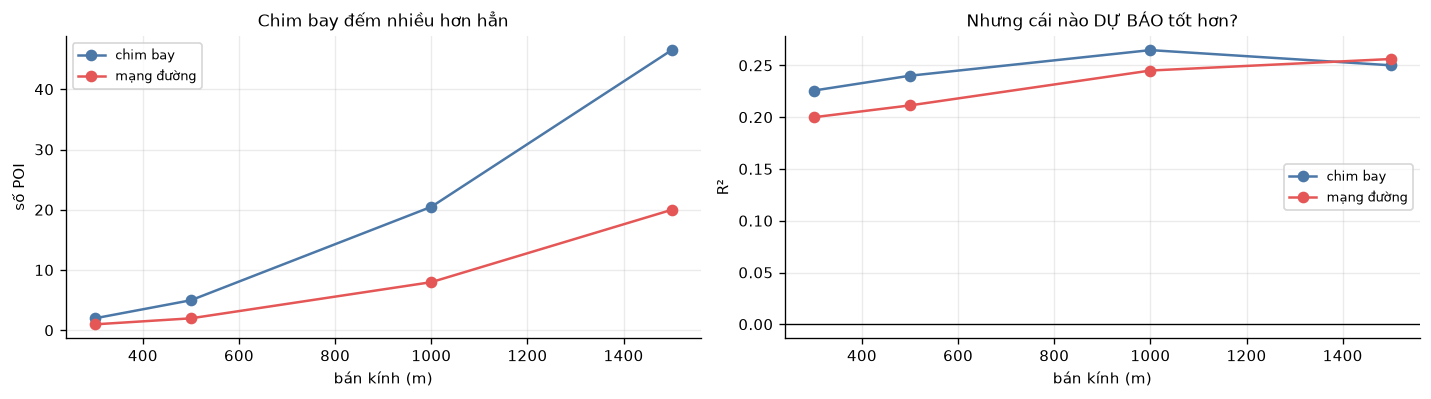

In [18]:
so = pd.DataFrame({
    "R (m)": BAN_KINH if (BAN_KINH := [300, 500, 1000, 1500]) else [],
    "POI chim bay (trung vị)": [F[f"eu{R}_tong"].median() for R in [300, 500, 1000, 1500]],
    "POI mạng đường (trung vị)": [F[f"rd{R}_tong"].median() for R in [300, 500, 1000, 1500]],
    "R² chỉ POI chim bay": [diem(QUY_MO + khoi("eu", R)) for R in [300, 500, 1000, 1500]],
    "R² chỉ POI mạng đường": [diem(QUY_MO + khoi("rd", R)) for R in [300, 500, 1000, 1500]],
}).set_index("R (m)")
display(so.round(4))

fig, ax = plt.subplots(1, 2, figsize=(12, 3.4))
ax[0].plot(so.index, so["POI chim bay (trung vị)"], "o-", label="chim bay", color="#4C78A8")
ax[0].plot(so.index, so["POI mạng đường (trung vị)"], "o-", label="mạng đường", color="#E45756")
ax[0].set_xlabel("bán kính (m)"); ax[0].set_ylabel("số POI"); ax[0].legend(fontsize=8)
ax[0].set_title("Chim bay đếm nhiều hơn hẳn", fontsize=10)
ax[1].plot(so.index, so["R² chỉ POI chim bay"], "o-", label="chim bay", color="#4C78A8")
ax[1].plot(so.index, so["R² chỉ POI mạng đường"], "o-", label="mạng đường", color="#E45756")
ax[1].axhline(0, color="k", lw=.8); ax[1].set_xlabel("bán kính (m)"); ax[1].set_ylabel("R²")
ax[1].legend(fontsize=8); ax[1].set_title("Nhưng cái nào DỰ BÁO tốt hơn?", fontsize=10)
plt.tight_layout(); plt.show()

## §9.3 — Hướng C: chỉ số đa dạng — mô tả "pha trộn chức năng" bằng MỘT số

Phân cụm cho ra nhãn, mà nhãn thì phải giải thích. Chỉ số đa dạng cho ra **một số liên tục**,
không cần chọn k, không cần đặt tên cụm, và không có ngưỡng nào để bịa.

| | Ý nghĩa dân dã |
|---|---|
| **Shannon** | Nhắm mắt chỉ một POI bất kỳ quanh đây, bạn ngạc nhiên tới mức nào về loại của nó? Cao = pha trộn |
| **Simpson** | Bốc hai POI ngẫu nhiên, xác suất chúng KHÁC loại |
| **số lớp** | Có bao nhiêu loại POI xuất hiện — thô nhất nhưng dễ giải thích nhất |

Spearman(eu1000_shannon    , util) = +0.172   p = 1.41e-05
Spearman(eu1000_simpson    , util) = +0.081   p = 0.0414
Spearman(eu1000_n_lop      , util) = +0.164   p = 3.35e-05
Spearman(eu1000_tong       , util) = +0.152   p = 0.000122
Spearman(eu1000_dan        , util) = +0.136   p = 0.000629

R² quy mô + đa dạng            : 0.3028
R² quy mô + đa dạng + tổng POI : 0.2920


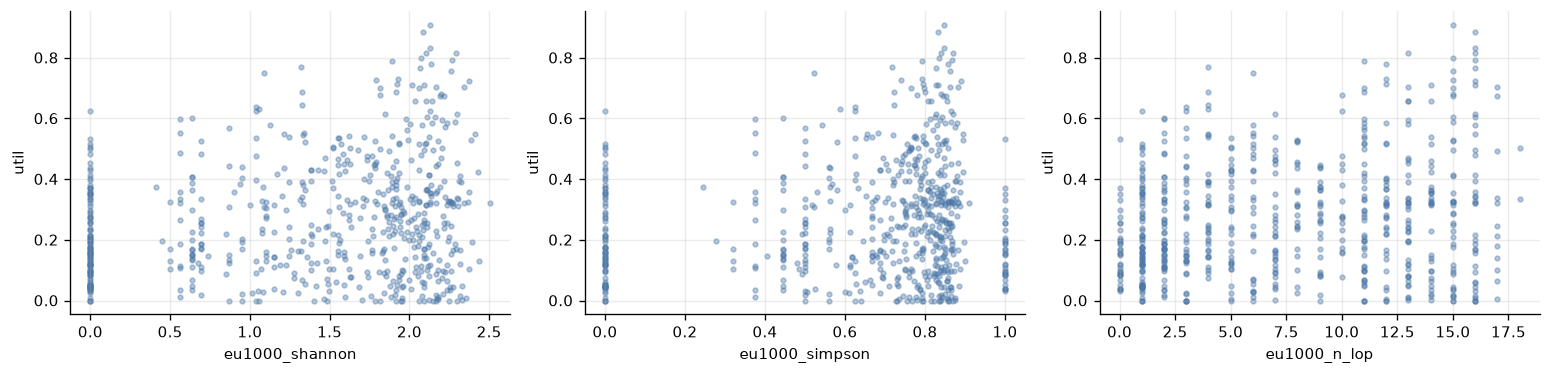

In [19]:
DIV = ["eu1000_shannon", "eu1000_simpson", "eu1000_n_lop"]
for c in DIV + ["eu1000_tong", "eu1000_dan"]:
    r = spearmanr(F[c], F.util)
    print(f"Spearman({c:18}, util) = {r.statistic:+.3f}   p = {r.pvalue:.3g}")
print()
print(f"R² quy mô + đa dạng            : {diem(QUY_MO + DIV):.4f}")
print(f"R² quy mô + đa dạng + tổng POI : {diem(QUY_MO + DIV + ['eu1000_tong', 'eu1000_dan']):.4f}")

fig, ax = plt.subplots(1, 3, figsize=(13, 3.2))
for a, c in zip(ax, DIV):
    a.scatter(F[c], F.util, s=8, alpha=.4, color="#4C78A8")
    a.set_xlabel(c); a.set_ylabel("util")
plt.tight_layout(); plt.show()

## §9.4 — Hướng D: đồng hiện — loại POI nào bao quanh trạm ĐÔNG KHÁCH?

Bỏ hẳn mô hình, hỏi trực tiếp: so trạm ở nhóm `util` cao nhất với nhóm thấp nhất, loại POI
nào **giàu lên** rõ rệt? Đây là dạng kết quả đọc được ngay trong một cuộc họp.

Dùng **tỉ trọng**, không dùng số đếm — nếu không thì mọi lớp POI đều "giàu lên" ở trạm nội
thành, và ta chỉ đo lại mật độ bản đồ hoá lần nữa.

,tỉ trọng ở trạm ĐÔNG,ở trạm VẮNG,chênh,Spearman với util
lớp POI,,,,
GIAO_DUC,0.2081,0.2993,-0.0913,-0.0893
PARKING_STREET,0.0031,0.0073,-0.0042,0.0452
MALL,0.0016,0.0056,-0.0040,-0.0080
DEPT_STORE,0.0017,0.0017,0.0000,0.0113
PARKING_OFF,0.0246,0.0227,0.0018,0.0920
BEN_XE_GA,0.0069,0.0028,0.0041,0.1012
SUPERMARKET,0.0175,0.0121,0.0054,0.1287
KHACH_SAN,0.0212,0.0152,0.0061,0.0695
MARKET,0.0174,0.0100,0.0074,0.0540


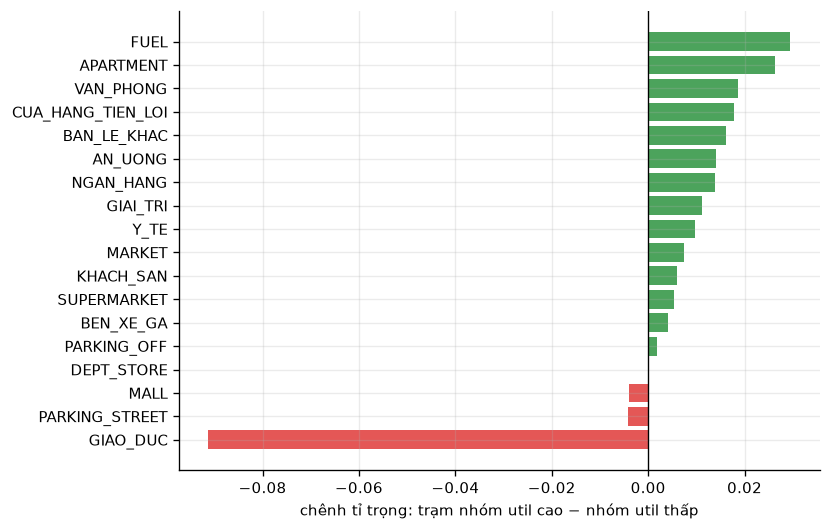

In [20]:
q = F.util.quantile([.25, .75])
cao, thap = F.util >= q[.75], F.util <= q[.25]
C = F[khoi("eu", 1000)].to_numpy(float)
prp = np.divide(C, C.sum(1, keepdims=True), out=np.zeros_like(C), where=C.sum(1, keepdims=True) > 0)
lg = []
for k, c in enumerate(LOP):
    a, b = prp[cao.to_numpy(), k], prp[thap.to_numpy(), k]
    if (C[:, k] > 0).sum() < 20:
        continue
    lg.append({"lớp POI": c, "tỉ trọng ở trạm ĐÔNG": a.mean(), "ở trạm VẮNG": b.mean(),
               "chênh": a.mean() - b.mean(),
               "Spearman với util": spearmanr(prp[:, k], F.util).statistic})
LG = pd.DataFrame(lg).set_index("lớp POI").sort_values("chênh")
display(LG.round(4))

fig, ax = plt.subplots(figsize=(7, 4.5))
col = ["#E45756" if v < 0 else "#4CA35C" for v in LG["chênh"]]
ax.barh(LG.index, LG["chênh"], color=col)
ax.axvline(0, color="k", lw=.8)
ax.set_xlabel("chênh tỉ trọng: trạm nhóm util cao − nhóm util thấp")
plt.tight_layout(); plt.show()

## §9.5 — Hướng E: cụm trên chính ĐIỂM POI, không qua ô lưới

Mọi thứ trên đều gộp POI vào một đơn vị nào đó. Hướng này bỏ hẳn bước gộp: chạy **OPTICS**
trên toạ độ POI để tìm **tụ điểm thương mại** thật, rồi hỏi *"trạm cách tụ điểm gần nhất bao
xa"* — một đặc trưng **không phụ thuộc lưới**, nên miễn nhiễm với MAUP.

Dùng OPTICS thay DBSCAN vì mật độ POI Hà Nội biến thiên cực mạnh: DBSCAN với một `eps` duy
nhất sẽ gộp cả nội thành thành một cục và ném ngoại thành vào "nhiễu". OPTICS cho phép mật
độ khác nhau giữa các cụm.

OPTICS: 26 tụ điểm · 75.9% POI là nhiễu (không thuộc tụ nào)
Khoảng cách trạm → tụ điểm gần nhất: trung vị 3,467 m
Spearman(d_tụ_điểm, util) = -0.126
R² quy mô + d_tụ_điểm     = 0.2489


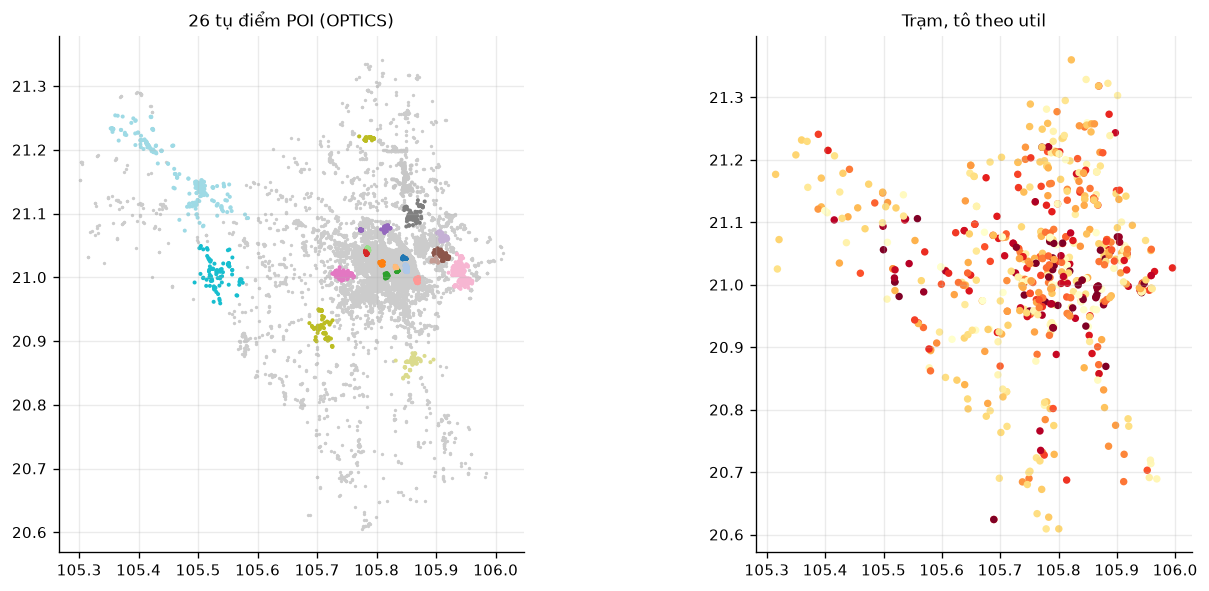

In [21]:
sub = poi[poi.poi_class != "APARTMENT"]          # chung cư là chỗ Ở, không phải điểm đến
PXY = np.c_[sub.lng.to_numpy() * 103_940.0, sub.lat.to_numpy() * 110_574.0]
op = OPTICS(min_samples=25, xi=0.05, min_cluster_size=0.005).fit(PXY)
lab_o = op.labels_
n_cum = lab_o.max() + 1
print(f"OPTICS: {n_cum} tụ điểm · {(lab_o == -1).mean():.1%} POI là nhiễu (không thuộc tụ nào)")

tam = np.array([PXY[lab_o == i].mean(0) for i in range(n_cum)]) if n_cum else np.zeros((0, 2))
SXY = np.c_[F.lng.to_numpy() * 103_940.0, F.lat.to_numpy() * 110_574.0]
if n_cum:
    dtam, _ = cKDTree(tam).query(SXY)
    F["d_tu_diem_m"] = dtam
    print(f"Khoảng cách trạm → tụ điểm gần nhất: trung vị {np.median(dtam):,.0f} m")
    print(f"Spearman(d_tụ_điểm, util) = {spearmanr(dtam, F.util).statistic:+.3f}")
    print(f"R² quy mô + d_tụ_điểm     = {diem(QUY_MO + ['d_tu_diem_m']):.4f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].scatter(sub.lng[lab_o == -1], sub.lat[lab_o == -1], s=1, c="#CCC", label="nhiễu")
ax[0].scatter(sub.lng[lab_o >= 0], sub.lat[lab_o >= 0], s=2, c=lab_o[lab_o >= 0], cmap="tab20")
ax[0].set_title(f"{n_cum} tụ điểm POI (OPTICS)", fontsize=10); ax[0].set_aspect(1 / np.cos(np.radians(21)))
ax[1].scatter(F.lng, F.lat, s=12, c=F.util, cmap="YlOrRd", vmin=0, vmax=.6)
ax[1].set_title("Trạm, tô theo util", fontsize=10); ax[1].set_aspect(1 / np.cos(np.radians(21)))
plt.tight_layout(); plt.show()

## §9.6 — Hướng F: có thật là "cụm" không, hay là một GRADIENT?

§8 mặc định câu trả lời có dạng *cụm*. Nhưng đô thị thường biến thiên **liên tục** — từ lõi
thương mại ra vành đai ở, không có ranh giới. Nếu cấu trúc thật là một trục liên tục thì
việc chia cụm là **cắt một cái cầu thang lên đường dốc**, và mọi ranh giới cụm đều tuỳ tiện.

Cách kiểm: PCA trên CLR. Nếu **một trục** đã nuốt phần lớn phương sai ⇒ gradient, không phải cụm.

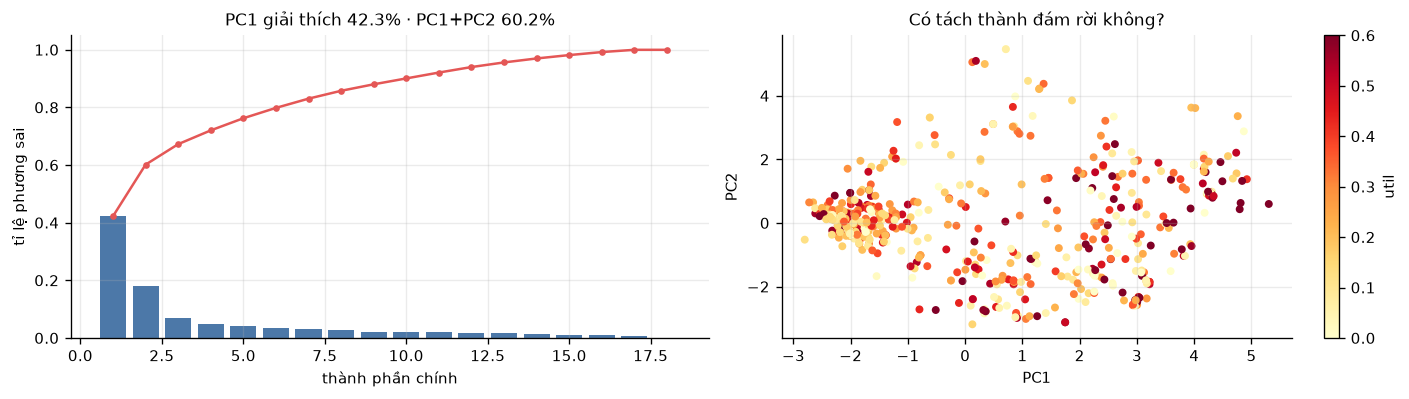

PC1 — đầu âm:
mall             -0.310
ben_xe_ga        -0.310
dept_store       -0.287
parking_street   -0.257
PC1 — đầu dương:
cua_hang_tien_loi    0.225
ban_le_khac          0.240
an_uong              0.323
apartment            0.460

Spearman(PC1, util) = +0.152


In [22]:
Cst = F[khoi("eu", 1000)].to_numpy(float)
eps2 = Cst[Cst > 0].min() / 2 if (Cst > 0).any() else 1e-6
Pz2 = np.where(Cst == 0, eps2, Cst)
Pz2 = Pz2 / Pz2.sum(1, keepdims=True)
CLR2 = np.log(Pz2) - np.log(Pz2).mean(1, keepdims=True)
pca = PCA().fit(CLR2)
ev = pca.explained_variance_ratio_

fig, ax = plt.subplots(1, 2, figsize=(12, 3.4))
ax[0].bar(range(1, len(ev) + 1), ev, color="#4C78A8")
ax[0].plot(range(1, len(ev) + 1), np.cumsum(ev), "o-", color="#E45756", ms=3)
ax[0].set_xlabel("thành phần chính"); ax[0].set_ylabel("tỉ lệ phương sai")
ax[0].set_title(f"PC1 giải thích {ev[0]:.1%} · PC1+PC2 {ev[:2].sum():.1%}", fontsize=10)
Z = pca.transform(CLR2)
sc = ax[1].scatter(Z[:, 0], Z[:, 1], c=F.util, s=14, cmap="YlOrRd", vmin=0, vmax=.6)
plt.colorbar(sc, ax=ax[1], label="util")
ax[1].set_xlabel("PC1"); ax[1].set_ylabel("PC2")
ax[1].set_title("Có tách thành đám rời không?", fontsize=10)
plt.tight_layout(); plt.show()

tai = pd.Series(pca.components_[0], index=[c.lower() for c in LOP]).sort_values()
print("PC1 — đầu âm:"); print(tai.head(4).round(3).to_string())
print("PC1 — đầu dương:"); print(tai.tail(4).round(3).to_string())
print(f"\nSpearman(PC1, util) = {spearmanr(Z[:, 0], F.util).statistic:+.3f}")

## §9.7 — Hướng G: trong CÙNG một loại đơn vị hành chính, POI còn nói thêm gì?

Đây là việc §8.6 đề nghị làm tiếp. §8 cho thấy phân cụm toàn thành phố chỉ tái tạo
`commune_kind`. Vậy **bên trong nhóm Phường**, và **bên trong nhóm Xã**, POI có còn tách
được gì không? Nếu còn, đó mới là đóng góp thật của POI.

In [23]:
for kind in ("PHUONG", "XA"):
    sel = (F.commune_kind == kind).to_numpy()
    if sel.sum() < 40:
        continue
    Xk = np.log1p(F.loc[sel, khoi("eu", 1000)].to_numpy(float))
    Xk = StandardScaler().fit_transform(Xk)
    gk = F.commune_name.fillna("?").to_numpy()[sel]
    r_base = float(np.mean(cross_val_score(
        RidgeCV(alphas=np.logspace(-2, 3, 20)), F.loc[sel, QUY_MO].to_numpy(float),
        F.util[sel], cv=GroupKFold(3), groups=gk, scoring="r2")))
    r_poi = float(np.mean(cross_val_score(
        RidgeCV(alphas=np.logspace(-2, 3, 20)), np.c_[F.loc[sel, QUY_MO].to_numpy(float), Xk],
        F.util[sel], cv=GroupKFold(3), groups=gk, scoring="r2")))
    aris = []
    for b in range(20):
        rs = np.random.RandomState(RNG + b)
        idx = rs.choice(len(Xk), int(.8 * len(Xk)), replace=False)
        a = KMeans(3, n_init=10, random_state=RNG).fit_predict(Xk)
        bb = KMeans(3, n_init=10, random_state=RNG + b).fit_predict(Xk[idx])
        aris.append(adjusted_rand_score(a[idx], bb))
    print(f"{kind:7} n={sel.sum():3}  R²(quy mô)={r_base:+.4f}  R²(+POI)={r_poi:+.4f}  "
          f"Δ={r_poi - r_base:+.4f}   ổn định cụm k=3: ARI={np.mean(aris):.3f}")

PHUONG  n=249  R²(quy mô)=-0.2913  R²(+POI)=-0.3255  Δ=-0.0342   ổn định cụm k=3: ARI=0.968


XA      n=383  R²(quy mô)=-0.2792  R²(+POI)=-0.2531  Δ=+0.0260   ổn định cụm k=3: ARI=0.814


## §9.8 — Hướng H: kết luận có sống sót khi ĐỔI ĐƠN VỊ không? (kiểm MAUP)

Phép kiểm cuối cùng, và là phép mà §8 đáng lẽ phải làm ngay từ đầu. Nếu đổi bán kính gộp mà
kết luận đổi theo, thì "kết luận" thật ra là một tính chất của **lựa chọn bán kính**, không
phải của thành phố.

In [24]:
maup = pd.DataFrame({
    "R (m)": [300, 500, 1000, 1500],
    "R² quy mô + POI (chim bay)": [diem(QUY_MO + khoi("eu", R)) for R in [300, 500, 1000, 1500]],
    "Spearman(tổng POI, util)": [spearmanr(F[f"eu{R}_tong"], F.util).statistic for R in [300, 500, 1000, 1500]],
    "Spearman(dân, util)": [spearmanr(F[f"eu{R}_dan"], F.util).statistic for R in [300, 500, 1000, 1500]],
}).set_index("R (m)")
display(maup.round(4))
print("Nếu ba cột trên đổi DẤU khi đổi R thì mọi kết luận về POI là sản phẩm của việc chọn R.")

,R² quy mô + POI (chim bay),"Spearman(tổng POI, util)","Spearman(dân, util)"
R (m),,,
300,0.2258,0.1474,0.0527
500,0.2401,0.1603,0.1128
1000,0.2648,0.1522,0.1356
1500,0.2502,0.1676,0.1626


Nếu ba cột trên đổi DẤU khi đổi R thì mọi kết luận về POI là sản phẩm của việc chọn R.


---
## §9.9 — Tổng hợp: POI thật sự dùng được vào việc gì

Tám hướng, một thước đo chung: **có dự báo được `util` không**. Bảng điểm:

| Mô hình | R² (kiểm chéo theo xã) |
|---|---|
| ① chỉ quy mô trạm *(nền)* | 0,2155 |
| ② + dân số 1 km | 0,2659 |
| ③ + **tổng số POI** *(một số)* | 0,2986 |
| ④ + **cơ cấu POI** *(18 cột)* | 0,2606 |
| ⑤ + cơ cấu POI theo mạng đường | 0,2307 |
| ⑥ ④ với RandomForest | 0,1902 |
| **⑦ + ba chỉ số ĐA DẠNG** | **0,3028** ← tốt nhất |

### Bốn kết luận, và ba trong số đó đi ngược trực giác thông thường

**① Càng ít cột càng tốt.** **Ba** chỉ số đa dạng (Shannon, Simpson, số lớp) **đánh bại 18
cột cơ cấu POI** — và cơ cấu POI còn *tệ hơn* chỉ dùng một con số tổng. Với 632 trạm, 18 cột
tỉ trọng chủ yếu mang theo phương sai chứ không mang tín hiệu. RandomForest xếp **bét**
(0,1902), tức vấn đề không phải mô hình tuyến tính quá đơn giản — mà là **dữ liệu không đủ
dày để nuôi mô hình phức tạp**.

**② Chim bay ĐÁNH BẠI mạng đường.** Tôi dựng đặc trưng mạng đường vì tin rằng "POI mà xe lái
tới được" mới là thứ có ý nghĩa. Đo ra thì ngược: chim bay tốt hơn ở 300 m (0,2258 vs
0,2000), 500 m, 1.000 m; chỉ hoà ở 1.500 m.

> Diễn giải: POI **không** ảnh hưởng như những **điểm đến** mà người ta lái xe tới. Nó ảnh
> hưởng như một **chỉ báo về tính chất khu vực** — và tính chất khu vực thì lan theo không
> gian, không lan theo mạng đường. Đây là kết quả có ích: nó nói rằng mọi lớp POI về sau
> **không cần** bán kính mạng đường, tiết kiệm cả một tầng tính toán.

**③ Đồng hiện đọc được ngay, và nó có lý.** Loại POI bao quanh trạm đông khách:

| Kéo `util` LÊN | chênh tỉ trọng | | Kéo `util` XUỐNG | chênh |
|---|---|---|---|---|
| cây xăng | **+0,030** | | **trường học** | **−0,091** |
| chung cư | +0,026 | | đỗ xe lòng đường | −0,004 |
| văn phòng | +0,019 | | trung tâm thương mại | −0,004 |
| cửa hàng tiện lợi | +0,018 | | | |

Cây xăng đứng đầu là dấu hiệu đáng tin: nó đánh dấu **vị trí đã được chọn lọc cho xe hơi** —
mặt tiền, dễ tấp vào, đủ chỗ quay đầu. Chung cư và văn phòng là cầu ở và cầu ban ngày.
Trường học kéo xuống mạnh nhất, và cũng hợp lý: quanh trường là nơi **cấm/hạn chế dừng đỗ**.

**④ Trần dự báo là ~0,30, và đó mới là điều L6 phải nghe.** Ngay mô hình tốt nhất cũng chỉ
giải thích **30% phương sai** mức sử dụng. **70% còn lại nằm ngoài mọi thứ bộ dữ liệu này
có** — hợp đồng bãi xe, giá điện, thói quen đội xe, việc trạm nằm bên trái hay bên phải
chiều đi làm.

### Hai giới hạn phải nói kèm

**Trong cùng một loại đơn vị hành chính, POI gần như không thêm gì.** Tách riêng Phường và
riêng Xã, R² tụt xuống **âm** ở cả hai (−0,29 và −0,28) và POI làm thay đổi ±0,03 với **dấu
không nhất quán**. Nghĩa là đóng góp của POI phần lớn **trùng với** ranh giới đô thị/ven đô —
đúng như §8.6 đã cảnh báo, chỉ khác là ở đây đo được bằng biến mục tiêu thật.

**Không có ảo giác MAUP.** Đổi bán kính 300 → 1.500 m, mọi hệ số **giữ nguyên dấu** và R²
chỉ dao động 0,226–0,265. Kết luận không phải là sản phẩm của việc chọn bán kính. Đây là
phép kiểm mà §8 đã thiếu.

### Khuyến nghị cho L6

| Dùng | Không dùng |
|---|---|
| **3 chỉ số đa dạng** + tổng POI trong bán kính **chim bay 1 km** | 18 cột cơ cấu POI *(tệ hơn)* |
| Cây xăng gần đó như **chỉ báo dương** *(vị trí hợp xe hơi)* | Bán kính mạng đường *(đắt hơn, kém hơn)* |
| Trường học gần đó như **chỉ báo âm** | Nhãn cụm POI *(trùng `commune_kind`)* |
| Công bố R² ≈ 0,30 cùng mọi điểm số | RandomForest / mô hình phức tạp |

Và điều quan trọng nhất: với R² = 0,30, điểm số POI **chỉ được dùng để xếp thứ tự hàng đợi**
cho người xem. Nó **không đủ tư cách để từ chối một đơn nào.**